In [11]:
import os
import re

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "1"  # 1
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/hpc/mp/spack/opt/spack/linux-ubuntu20.04-zen2/gcc-10.3.0/cuda-11.4.4-ctldo35wmmwws3jbgwkgjjcjawddu3qz/"

import tensorflow as tf

keras = tf.keras  # fixes issues with vsCode
from keras import backend as K
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 13})

from functools import partial

from keras import Input, Model
from keras.preprocessing.image import ImageDataGenerator
from keras.layers import (
    Layer,
    LeakyReLU,
    Add,
    UpSampling2D,
    Activation,
    SpatialDropout2D,
    Conv2D,
    BatchNormalization,
    Concatenate,
    Flatten,
    Dense,
    RandomRotation,
    RandomFlip,
    RandomZoom,
)
from keras.optimizers import Adam

from IPython.display import clear_output
from datetime import datetime

from tensorflow import pad
from tensorflow_addons.layers import InstanceNormalization

from keras.callbacks import (
    LambdaCallback,
    TensorBoard,
    EarlyStopping,
    ModelCheckpoint,
    LearningRateScheduler,
)

import h5py
import healpy as hp

%matplotlib inline

# tf.debugging.set_log_device_placement(False)

print(f"tf version: {tf.__version__}")
gpus = tf.config.list_physical_devices("GPU")
print(gpus)
# print(tf.config.experimental.get_memory_info('GPU:0'))
# tf.config.experimental.set_memory_growth(gpus[0], True)

tf version: 2.12.0
[]


We used MirroredStrategy to allow for multiGPU setups, can use onedevice if you need to debug things and don't want to change server settings.

You need to use `with strategy.scope():` anytime you call a tensorflow function with this code or you will get errors.

In [12]:
strategy = tf.distribute.MirroredStrategy()
# stragety = tf.distribute.OneDeviceStrategy(device="/gpu:0") # for debugging

# config = tf.ConfigProto()
# config.gpu_options.allow_growth = True

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


### Helper Functions

In [13]:
class ReflectionPadding2D(Layer):
    def __init__(self, padding=(1, 1), **kwargs):
        self.padding = tuple(padding)
        self.input_spec = [tf.keras.layers.InputSpec(ndim=4)]
        super(ReflectionPadding2D, self).__init__(**kwargs)

    def compute_output_shape(self, s):
        """If you are using "channels_last" configuration"""
        return (s[0], s[1] + 2 * self.padding[0], s[2] + 2 * self.padding[1], s[3])

    def call(self, x, mask=None):
        w_pad, h_pad = self.padding
        return pad(x, [[0, 0], [h_pad, h_pad], [w_pad, w_pad], [0, 0]], "REFLECT")


def create_localization_module(input_layer, n_filters):
    layer1 = ReflectionPadding2D()(input_layer)
    convolution1 = create_convolution_block(layer1, n_filters)
    return create_convolution_block(convolution1, n_filters, kernel=(1, 1))


def create_up_sampling_module(input_layer, n_filters, size=(2, 2)):
    up_sample = UpSampling2D(size=size)(input_layer)
    layer1 = ReflectionPadding2D()(up_sample)
    return create_convolution_block(layer1, n_filters)


def create_context_module(
    input_layer, n_level_filters, dropout_rate=0.1, data_format="channels_last"
):
    layer1 = ReflectionPadding2D()(input_layer)
    convolution1 = create_convolution_block(
        input_layer=layer1, n_filters=n_level_filters
    )
    dropout = SpatialDropout2D(rate=dropout_rate, data_format=data_format)(convolution1)
    layer2 = ReflectionPadding2D()(dropout)
    return create_convolution_block(
        input_layer=layer2, n_filters=n_level_filters
    )


def create_convolution_block(
    input_layer,
    n_filters,
    batch_normalization=False,
    kernel=(3, 3),
    activation=LeakyReLU,
    padding="valid",
    strides=(1, 1),
    instance_normalization=False,
):
    """
    :param strides:
    :param input_layer:
    :param n_filters:
    :param batch_normalization:
    :param kernel:
    :param activation: Keras activation layer to use. (default is 'relu')
    :param padding:
    :return:
    """
    layer = Conv2D(n_filters, kernel, padding=padding, strides=strides)(input_layer)
    if batch_normalization:
        layer = BatchNormalization()(layer)
    elif instance_normalization:
        layer = InstanceNormalization()(layer)
    return Activation("relu")(layer) if activation is None else activation()(layer)


def dice_coefficient(y_true, y_pred, smooth=1.0):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


def dice_coefficient_loss(y_true, y_pred):
    return -dice_coefficient(y_true, y_pred)

with strategy.scope():
    create_convolution_block = partial(create_convolution_block, activation=LeakyReLU, instance_normalization=True)

### Model Architecture

In [14]:
def isensee2017_model(
    inputs,
    n_base_filters=16,
    depth=5,
    dropout_rate=0.3,
    n_segmentation_levels=3,
    n_labels=1,
    optimizer=Adam,
    initial_learning_rate=5e-4,
    loss_function=dice_coefficient_loss,
    activation_name="relu",
    name=''
):
    """
    This function builds a model proposed by Isensee et al. for the BRATS 2017 competition:
    https://www.cbica.upenn.edu/sbia/Spyridon.Bakas/MICCAI_BraTS/MICCAI_BraTS_2017_proceedings_shortPapers.pdf
    This network is highly similar to the model proposed by Kayalibay et al. "CNN-based Segmentation of Medical
    Imaging Data", 2017: https://arxiv.org/pdf/1701.03056.pdf
    :param inputs:
    :param n_base_filters:
    :param depth:
    :param dropout_rate:
    :param n_segmentation_levels:
    :param n_labels:
    :param optimizer:
    :param initial_learning_rate:
    :param loss_function:
    :param activation_name:
    :return:
    """

    current_layer = inputs
    level_output_layers = []
    level_filters = []
    # n_level_filters = (2**level_number) * n_base_filters
    n_level_filters = 8
    for _ in range(depth):
        level_filters.append(n_level_filters)

        if current_layer is inputs:
            layer = ReflectionPadding2D()(current_layer)
            in_conv = create_convolution_block(layer, n_level_filters)
        else:
            layer = ReflectionPadding2D()(current_layer)
            in_conv = create_convolution_block(layer, n_level_filters, strides=(2, 2))

        context_output_layer = create_context_module(
            in_conv, n_level_filters, dropout_rate=dropout_rate
        )

        summation_layer = Add()([in_conv, context_output_layer])
        level_output_layers.append(summation_layer)
        current_layer = summation_layer

    segmentation_layers = []
    for level_number in range(depth - 2, -1, -1):
        up_sampling = create_up_sampling_module(
            current_layer, level_filters[level_number]
        )
        concatenation_layer = Concatenate()(
            [level_output_layers[level_number], up_sampling]
        )
        localization_output = create_localization_module(
            concatenation_layer, level_filters[level_number]
        )
        current_layer = localization_output
        if level_number < n_segmentation_levels:
            segmentation_layers.insert(0, Conv2D(n_labels, (1, 1))(current_layer))

    output_layer = None
    for level_number in reversed(range(n_segmentation_levels - 1)):
        segmentation_layer = segmentation_layers[level_number]
        if output_layer is None:
            output_layer = segmentation_layer
        else:
            output_layer = Add()([output_layer, segmentation_layer])

        if level_number > 0:
            output_layer = UpSampling2D(size=(2, 2))(output_layer)

    flat_layer = Flatten()(output_layer)
    out_layer = Dense(1, activation=None)(flat_layer)

    model = Model(inputs=inputs, outputs=out_layer, name=name)
    model.compile(
        optimizer=optimizer(learning_rate=initial_learning_rate),
        loss=loss_function,
        metrics=tf.keras.metrics.RootMeanSquaredError(),
    )
    return model


In [15]:
def make_bs_model(
    inputs,
    depth=5,
    dropout_rate=0.3,
    optimizer=Adam,
    initial_learning_rate=5e-4,
    loss_function=dice_coefficient_loss,
    name="custom_model",
    preprocess=False,
):
    if preprocess:
        inputs = RandomFlip("horizontal")(inputs)
        # inputs = RandomZoom(0.2)(inputs)
        inputs = RandomRotation(np.pi)(inputs)

    current_layer = inputs
    level_output_layers = []
    level_filters = []
    n_level_filters = 16 
    for _ in range(depth):
        level_filters.append(n_level_filters)

        if current_layer is inputs:
            layer = ReflectionPadding2D()(current_layer)
            in_conv = create_convolution_block(layer, n_level_filters)
        else:
            layer = ReflectionPadding2D()(current_layer)
            in_conv = create_convolution_block(layer, n_level_filters, strides=(2, 2))

        context_output_layer = create_context_module(
            in_conv, n_level_filters, dropout_rate=dropout_rate
        )
        summation_layer = Add()([in_conv, context_output_layer])
        level_output_layers.append(summation_layer)
        current_layer = summation_layer

    flat_layer = Flatten()(current_layer)
    out_layer = Dense(1, activation=None)(flat_layer)

    model = Model(inputs=inputs, outputs=out_layer, name=name)
    model.compile(
        optimizer=optimizer(learning_rate=initial_learning_rate),
        loss=loss_function,
        metrics=tf.keras.metrics.RootMeanSquaredError(),
    )
    return model

In [16]:
# model settins, will also be used to inform data loading
batch_size = 16
max_epochs = 8

save_models=True
debug = True

In [17]:
nside = 1024
nsims = 100
npatches = 10
fnl_range = [-1000, 1000]
pols = 'T'
lensed = True

npol = len(pols)

In [18]:
def mk_dir(dir):
    if not os.path.exists(dir):
        print(f"Creating dir: {dir}")
        os.makedirs(dir)
    else:
        print(f'Using existing folder: {dir}')

use_tensorboard = True

# some base settings for files
model_name = "ksw"
data_dir = f"data/{model_name}/{'lensed' if lensed else 'unlensed'}"
model_dir = f"{data_dir}/models"
plot_dir = f"{data_dir}/plots"
tb_dir = f"{data_dir}/tensorboard"

basename = f'{nside}_{pols}_{nsims}x{npatches}_fnl{fnl_range[0]}-{fnl_range[1]}'
run_time = datetime.now().strftime("%Y%m%d-%H%M%S")

print('Using data file', basename)
mk_dir(data_dir)
mk_dir(model_dir)
mk_dir(plot_dir)
if use_tensorboard:
    mk_dir(tb_dir)

Using data file 1024_T_100x10_fnl-1000-1000
Using existing folder: data/ksw/lensed
Using existing folder: data/ksw/lensed/models
Using existing folder: data/ksw/lensed/plots
Using existing folder: data/ksw/lensed/tensorboard


In [21]:
def load_data(data_dir, base_name, pol=0):
    # Open the file in read mode
    with h5py.File(f'{data_dir}/{base_name}.hdf5', 'r') as hdf:
        # Load data into variables
        fnls = hdf.get('fnls')[()]
        patches = hdf.get('patches')[()]
        return fnls, patches

In [26]:
train_size = nsims*npatches
N_train = int(train_size * 0.8)
N_val = int(train_size * 0.1)
N_test = int(train_size * 0.1)

fnls, data = load_data(data_dir, basename)
fnls = np.repeat(fnls, npatches, axis=0)
data = data.reshape(-1, nside, nside)
print(f'Loaded data shape: {data.shape}, fnl shape: {fnls.shape}') #, maps shape: {maps.shape}')

# split into training and testing data
X_train = data[:N_train]
X_test = data[N_train : N_train + N_test]
X_val = data[N_train + N_test : N_train + N_test + N_val]

y_train = fnls[:N_train]
y_test = fnls[N_train : N_train + N_test]
y_val = fnls[N_train + N_test : N_train + N_test + N_val]

print(f'Train data shape: {X_train.shape}, fnls: {y_train.shape}')
print(f'Validations data shape: {X_val.shape}, fnls: {y_val.shape}')
print(f'Test data shape: {X_test.shape}, fnls: {y_test.shape}')

# Our sets are not big enought to do really complex loading into ram, but we still need to do stuff for the gpu
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size, num_parallel_calls=tf.data.AUTOTUNE)

Loaded data shape: (1000, 1024, 1024), fnl shape: (1000,)
Train data shape: (800, 1024, 1024), fnls: (800,)
Validations data shape: (100, 1024, 1024), fnls: (100,)
Test data shape: (100, 1024, 1024), fnls: (100,)


### Check Data

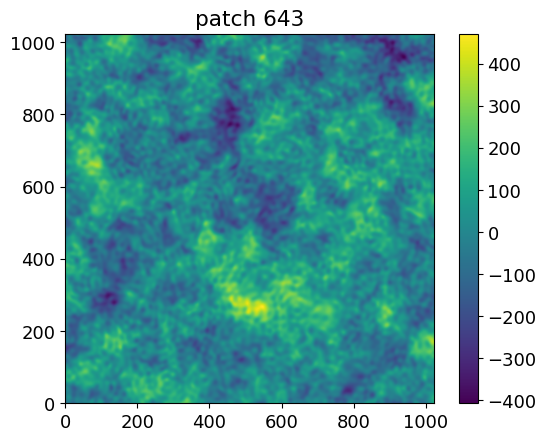

In [27]:
if debug:
    ri = np.random.randint(len(data))
    plt.imshow(data[ri], origin="lower")
    plt.title(f"patch {ri}")
    plt.colorbar()
    plt.savefig(f"{plot_dir}/{basename}_example.png")
    plt.show()

## Train Model

Set up callbacks for both models.

In [28]:
with strategy.scope():
    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=1e-5, decay_steps=1000, decay_rate=0.9
    )

    callbacks = [
        EarlyStopping(monitor="val_root_mean_squared_error", patience=10),
        ModelCheckpoint(
            filepath=f"{model_dir}/checkpoint_{run_time}.keras",
            monitor="val_root_mean_squared_error",
            save_best_only=True,
        ),
        # LearningRateScheduler(lr_schedule),
    ]
    if use_tensorboard:
        logs = f"{tb_dir}/{basename}_{run_time}"
        callbacks.append(TensorBoard(log_dir=logs))

In [29]:
with strategy.scope():
    input_img = Input((nside, nside, 1), name="img")
    isensee_model = isensee2017_model(
        input_img,
        depth=5,
        n_segmentation_levels=3,
        dropout_rate=0.3,
        loss_function=tf.keras.losses.mse,
        initial_learning_rate=1e-3,
        name=f"{model_name}-isensee-{basename}",
    )
    if debug:
        isensee_model.summary()

Model: "ksw-isensee-1024_T_100x10_fnl-1000-1000"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 img (InputLayer)               [(None, 1024, 1024,  0           []                               
                                 1)]                                                              
                                                                                                  
 reflection_padding2d (Reflecti  (None, 1026, 1026,   0          ['img[0][0]']                    
 onPadding2D)                   1)                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 1024, 1024,   80          ['reflection_padding2d[0][0]']   
                                8)                          

In [30]:
with strategy.scope(): 
    isensee_model.fit(
        train_dataset,
        validation_data=val_dataset,
        batch_size=batch_size,
        epochs=max_epochs,
        callbacks=callbacks,
    )

    if save_models:
        modelfile = f"{model_dir}/{basename}-isensee_{run_time}"
        isensee_model.save(modelfile)

2023-06-24 11:53:15.120763: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:786] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorSliceDataset/_2"
op: "TensorSliceDataset"
input: "Placeholder/_0"
input: "Placeholder/_1"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_DOUBLE
      type: DT_DOUBLE
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 800
  }
}
attr {
  key: "is_files"
  value {
    b: false
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\024TensorSliceDataset:6"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
        dim {
          size: 1024
        }
        dim {
          size: 1024
        }
      }
      shape {
      }
    }
  }
}
attr {
  key: "replicate_on_split"
  value {
    b: false
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args 

Epoch 1/8
50/50 [==============================] - ETA: 0s - loss: 8745.8428 - root_mean_squared_error: 93.5192 

2023-06-24 12:05:31.347890: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:786] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorSliceDataset/_2"
op: "TensorSliceDataset"
input: "Placeholder/_0"
input: "Placeholder/_1"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_DOUBLE
      type: DT_DOUBLE
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 100
  }
}
attr {
  key: "is_files"
  value {
    b: false
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\025TensorSliceDataset:10"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
        dim {
          size: 1024
        }
        dim {
          size: 1024
        }
      }
      shape {
      }
    }
  }
}
attr {
  key: "replicate_on_split"
  value {
    b: false
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args

50/50 [==============================] - 743s 15s/step - loss: 8745.8428 - root_mean_squared_error: 93.5192 - val_loss: 846.8098 - val_root_mean_squared_error: 29.1000
Epoch 2/8
50/50 [==============================] - ETA: 0s - loss: 716.8657 - root_mean_squared_error: 26.7743 

2023-06-24 12:17:48.046354: W tensorflow/core/framework/dataset.cc:807] Input of GeneratorDatasetOp::Dataset will not be optimized because the dataset does not implement the AsGraphDefInternal() method needed to apply optimizations.


...

50/50 [==============================] - 737s 15s/step - loss: 1007.8531 - root_mean_squared_error: 31.7467 - val_loss: 4029.2656 - val_root_mean_squared_error: 63.4765
Epoch 5/8
50/50 [==============================] - ETA: 0s - loss: 3573.2520 - root_mean_squared_error: 59.7767 

2023-06-24 12:54:44.124315: W tensorflow/core/framework/dataset.cc:807] Input of GeneratorDatasetOp::Dataset will not be optimized because the dataset does not implement the AsGraphDefInternal() method needed to apply optimizations.


50/50 [==============================] - 739s 15s/step - loss: 3573.2520 - root_mean_squared_error: 59.7767 - val_loss: 8007.4424 - val_root_mean_squared_error: 89.4843
Epoch 6/8
50/50 [==============================] - ETA: 0s - loss: 4028.5242 - root_mean_squared_error: 63.4707 

2023-06-24 13:07:06.982040: W tensorflow/core/framework/dataset.cc:807] Input of GeneratorDatasetOp::Dataset will not be optimized because the dataset does not implement the AsGraphDefInternal() method needed to apply optimizations.


50/50 [==============================] - 741s 15s/step - loss: 4028.5242 - root_mean_squared_error: 63.4707 - val_loss: 628.6973 - val_root_mean_squared_error: 25.0738
Epoch 7/8
45/50 [==========================>...] - ETA: 1:12 - loss: 2724.8513 - root_mean_squared_error: 52.2001

In [ ]:
with strategy.scope():
    input_img = Input((nside, nside, 1), name="img")
    bs_model = make_bs_model(
        input_img,
        depth=6,
        dropout_rate=0.3,
        loss_function=tf.keras.losses.mse,
        initial_learning_rate=1e-3,
        preprocess=True,
        name=f"{model_name}-{basename}",
    )
    
    if debug:
        bs_model.summary()


In [ ]:
with strategy.scope():
    bs_model.fit(
        train_dataset,
        validation_data=val_dataset,
        batch_size=batch_size,
        epochs=max_epochs,
        callbacks=callbacks,
    )

    if save_models:
        modelfile = f"{model_dir}/{basename}_{run_time}"
        bs_model.save(modelfile)

# Validation

Simple validation checks on the three datasets. The model has seen train and val before, so those results are not as important as the test results which have not been seen by the model yet.

In [ ]:
if debug:
    # check the accuracy of some training data
    ipreds = isensee_model.predict(X_train, batch_size=batch_size, verbose="auto")[:, 0]
    bpreds = bs_model.predict(X_train, batch_size=batch_size, verbose="auto")[:, 0]
    truth = y_train

    irmse = np.sqrt(((ipreds - truth) ** 2).mean())
    brmse = np.sqrt(((bpreds - truth) ** 2).mean())

    plt.plot(truth, ipreds, ".", label=f'isensee: {irmse:.2f}')
    plt.plot(truth, bpreds, ".", label=f'bs: {brmse:.2f}')
    plt.plot(truth, truth, ",")
    plt.xlabel("truth (train)")
    plt.grid()
    plt.ylabel("prediction")
    plt.legend()
    plt.savefig(f"{plot_dir}/{basename}_train.png")
    plt.show()

In [ ]:
if debug:
    ipreds = isensee_model.predict(X_val, batch_size=batch_size, verbose="auto")[:, 0]
    bpreds = bs_model.predict(X_val, batch_size=batch_size, verbose="auto")[:, 0]
    truth = y_val

    irmse = np.sqrt(((ipreds - truth) ** 2).mean())
    brmse = np.sqrt(((bpreds - truth) ** 2).mean())

    plt.plot(truth, ipreds, ".", label=f'isensee: {irmse:.2f}')
    plt.plot(truth, bpreds, ".", label=f'bs: {brmse:.2f}')
    plt.plot(truth, truth, ",")
    plt.xlabel("truth (val)")
    plt.grid()
    plt.ylabel("prediction")
    plt.legend()
    plt.savefig(f"{plot_dir}/{basename}_val.png")
    plt.show()

Model has not seen the test data, so this is the best view of preformance.

In [ ]:
if debug:
    ipreds = isensee_model.predict(X_test, batch_size=batch_size, verbose="auto")[:, 0]
    bpreds = bs_model.predict(X_test, batch_size=batch_size, verbose="auto")[:, 0]
    truth = y_test

    irmse = np.sqrt(((ipreds - truth) ** 2).mean())
    brmse = np.sqrt(((bpreds - truth) ** 2).mean())

    plt.plot(truth, ipreds, ".", label=f'isensee: {irmse:.2f}')
    plt.plot(truth, bpreds, ".", label=f'bs: {brmse:.2f}')
    plt.plot(truth, truth, ",")
    plt.xlabel("truth (test)")
    plt.grid()
    plt.ylabel("prediction")
    plt.legend()

    plt.savefig(f"{plot_dir}/{basename}_test.png")
    plt.show()